# Supply Chain & Inventory Analytics

## Project Objective

The objective of this project is to analyze supply chain,
inventory, supplier, warehouse and order data to identify:

- Inventory problems
- Product demand patterns
- Supplier performance
- Warehouse efficiency
- Stockout risks
- Overstock situations
- Delivery performance
- Revenue and profitability opportunities

Tools:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
!pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install pandas numpy matplotlib seaborn plotly openpyxl scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [5]:
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 3.0.5
NumPy: 2.5.2


## Load Dataset

In [6]:
df = pd.read_csv(r"C:\Users\pc\Desktop\Supply_Chain_Inventory\supply_chain_inventory_30000_transactions.csv")

In [7]:
df.head()

,Order_ID,Order_Date,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Warehouse,Region,Quantity_Ordered,Quantity_Sold,Unit_Cost,Unit_Price,Inventory_Level,Reorder_Level,Lead_Time_Days,Delivery_Days,Order_Status,Shipping_Cost,Defective_Units
0,ORD100000,2025-01-01,P016,Laptop Sleeve,Accessories,S001,TechSource India,Pune WH,West,16,16,376.09,677.77,94,27,3,2.0,Completed,229.41,0
1,ORD100001,2025-10-29,P010,Desk Lamp,Furniture,S003,Metro Wholesale,Delhi WH,North,13,11,654.21,1079.96,60,18,9,9.0,Completed,178.20,0
2,ORD100002,2025-02-12,P017,Water Bottle,Accessories,S006,National Distributors,Pune WH,West,25,22,179.03,355.02,132,49,14,12.0,Completed,336.53,0
3,ORD100003,2025-09-25,P014,Printer Paper,Stationery,S004,Reliable Traders,Delhi WH,North,12,11,201.93,340.05,25,35,10,8.0,Completed,161.62,0
4,ORD100004,2025-01-07,P002,Mechanical Keyboard,Electronics,S002,Prime Components,Pune WH,West,6,4,1459.92,2309.17,49,15,15,13.0,Completed,106.83,0


In [8]:
df.tail()


,Order_ID,Order_Date,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Warehouse,Region,Quantity_Ordered,Quantity_Sold,Unit_Cost,Unit_Price,Inventory_Level,Reorder_Level,Lead_Time_Days,Delivery_Days,Order_Status,Shipping_Cost,Defective_Units
29995,ORD129995,2025-02-02,P015,Backpack,Accessories,S006,National Distributors,Pune WH,West,14,14,726.44,1307.51,30,14,7,8.0,Completed,137.26,0
29996,ORD129996,2025-10-01,P011,Notebook Pack,Stationery,S003,Metro Wholesale,Mumbai WH,West,26,22,89.04,181.93,117,46,10,10.0,Completed,368.58,0
29997,ORD129997,2025-07-20,P012,Ball Pen Pack,Stationery,S001,TechSource India,Mumbai WH,West,35,25,53.80,95.93,31,72,6,8.0,Completed,367.91,1
29998,ORD129998,2025-10-01,P020,Yoga Mat,Sports,S006,National Distributors,Pune WH,West,29,24,427.12,799.64,60,31,6,6.0,Completed,139.73,0
29999,ORD129999,2025-10-06,P003,USB-C Cable,Electronics,S001,TechSource India,Pune WH,West,29,29,118.36,245.77,89,44,10,11.0,Completed,153.49,0


## Understand the Dataset

In [9]:
df.shape

(30000, 20)

In [10]:
df.columns

Index(['Order_ID', 'Order_Date', 'Product_ID', 'Product_Name', 'Category',
       'Supplier_ID', 'Supplier_Name', 'Warehouse', 'Region',
       'Quantity_Ordered', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price',
       'Inventory_Level', 'Reorder_Level', 'Lead_Time_Days', 'Delivery_Days',
       'Order_Status', 'Shipping_Cost', 'Defective_Units'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          30000 non-null  str    
 1   Order_Date        30000 non-null  str    
 2   Product_ID        30000 non-null  str    
 3   Product_Name      30000 non-null  str    
 4   Category          30000 non-null  str    
 5   Supplier_ID       30000 non-null  str    
 6   Supplier_Name     30000 non-null  str    
 7   Warehouse         30000 non-null  str    
 8   Region            30000 non-null  str    
 9   Quantity_Ordered  30000 non-null  int64  
 10  Quantity_Sold     30000 non-null  int64  
 11  Unit_Cost         30000 non-null  float64
 12  Unit_Price        30000 non-null  float64
 13  Inventory_Level   30000 non-null  int64  
 14  Reorder_Level     30000 non-null  int64  
 15  Lead_Time_Days    30000 non-null  int64  
 16  Delivery_Days     25133 non-null  float64
 17  Orde

In [12]:
df.describe()

,Quantity_Ordered,Quantity_Sold,Unit_Cost,Unit_Price,Inventory_Level,Reorder_Level,Lead_Time_Days,Delivery_Days,Shipping_Cost,Defective_Units
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,25133.000000,30000.000000,30000.000000
mean,15.742033,11.546533,951.883138,1497.263840,53.255400,27.361100,8.470133,8.996459,175.089714,0.204067
std,7.614378,8.010009,1548.830205,2203.851209,39.546019,14.476996,4.020487,4.355523,73.738225,0.470989
min,1.000000,0.000000,48.740000,90.970000,2.000000,5.000000,2.000000,1.000000,48.120000,0.000000
25%,10.000000,6.000000,113.560000,209.025000,23.000000,17.000000,5.000000,5.000000,119.700000,0.000000
50%,15.000000,11.000000,344.135000,691.125000,43.000000,25.000000,8.000000,9.000000,159.540000,0.000000
75%,21.000000,17.000000,905.242500,1544.907500,73.000000,36.000000,12.000000,12.000000,215.630000,0.000000
max,55.000000,51.000000,8071.200000,10730.450000,257.000000,75.000000,15.000000,18.000000,602.740000,4.000000


## Data Cleaning

In [13]:
df.isnull().sum()

Order_ID               0
Order_Date             0
Product_ID             0
Product_Name           0
Category               0
Supplier_ID            0
Supplier_Name          0
Warehouse              0
Region                 0
Quantity_Ordered       0
Quantity_Sold          0
Unit_Cost              0
Unit_Price             0
Inventory_Level        0
Reorder_Level          0
Lead_Time_Days         0
Delivery_Days       4867
Order_Status           0
Shipping_Cost          0
Defective_Units        0
dtype: int64

In [14]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(ascending=False)

Delivery_Days       16.223333
Order_ID             0.000000
Product_ID           0.000000
Order_Date           0.000000
Product_Name         0.000000
Category             0.000000
Supplier_Name        0.000000
Supplier_ID          0.000000
Region               0.000000
Quantity_Ordered     0.000000
Quantity_Sold        0.000000
Warehouse            0.000000
Unit_Cost            0.000000
Unit_Price           0.000000
Reorder_Level        0.000000
Inventory_Level      0.000000
Lead_Time_Days       0.000000
Order_Status         0.000000
Shipping_Cost        0.000000
Defective_Units      0.000000
dtype: float64

In [15]:
df.duplicated().sum()


np.int64(0)

In [16]:
df = df.drop_duplicates()

### Convert Date

In [17]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [18]:
df["Order_Date"].dtype

dtype('<M8[us]')

### Create Useful Columns

#### Revenue

In [19]:
df["Revenue"] = (
    df["Quantity_Sold"] * df["Unit_Price"]
)

#### Product Cost

In [20]:
df["Product_Cost"] = (
    df["Quantity_Sold"] * df["Unit_Cost"]
)

#### Profit

In [21]:
df["Profit"] = (
    df["Revenue"] - df["Product_Cost"] - df["Shipping_Cost"]
)

#### Profit Margin

In [22]:
df["Profit_Margin"] = (
    df["Profit"] / df["Revenue"]
) * 100

## Inventory Analysis

#### Current inventory

In [23]:
# Display basic statistical information about the Inventory_Level column.
# This helps us understand the minimum, maximum, average,
# and distribution of inventory levels.

df["Inventory_Level"].describe()

count    30000.000000
mean        53.255400
std         39.546019
min          2.000000
25%         23.000000
50%         43.000000
75%         73.000000
max        257.000000
Name: Inventory_Level, dtype: float64

#### Find products with low inventory

In [24]:
# Select rows where the current inventory is
# less than or equal to the reorder level.
#
# These products may need to be reordered soon.

low_stock = df[
    df["Inventory_Level"] <= df["Reorder_Level"]
]

# Display the first 10 low-stock records
low_stock.head(10)

,Order_ID,Order_Date,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Warehouse,Region,Quantity_Ordered,...,Reorder_Level,Lead_Time_Days,Delivery_Days,Order_Status,Shipping_Cost,Defective_Units,Revenue,Product_Cost,Profit,Profit_Margin
3,ORD100003,2025-09-25,P014,Printer Paper,Stationery,S004,Reliable Traders,Delhi WH,North,12,...,35,10,8.0,Completed,161.62,0,3740.55,2221.23,1357.70,36.296801
7,ORD100007,2025-12-11,P016,Laptop Sleeve,Accessories,S001,TechSource India,Pune WH,West,21,...,17,14,16.0,Completed,246.99,0,12821.39,6317.50,6256.90,48.800481
12,ORD100012,2025-03-20,P013,Marker Set,Stationery,S008,Apex Supplies,Bengaluru WH,South,15,...,34,7,5.0,Completed,238.49,1,2310.12,1303.08,768.55,33.268835
15,ORD100015,2025-10-14,P004,Bluetooth Speaker,Electronics,S006,National Distributors,Pune WH,West,7,...,12,14,17.0,Completed,94.47,0,11589.41,6313.79,5181.15,44.705900
16,ORD100016,2025-11-09,P011,Notebook Pack,Stationery,S006,National Distributors,Pune WH,West,35,...,34,13,13.0,Completed,446.39,2,5320.64,2720.96,2153.29,40.470507
21,ORD100021,2025-04-11,P007,Office Chair,Furniture,S006,National Distributors,Hyderabad WH,South,6,...,7,11,11.0,Completed,98.60,0,28183.80,19809.68,8275.52,29.362684
27,ORD100027,2025-04-01,P001,Wireless Mouse,Electronics,S001,TechSource India,Hyderabad WH,South,9,...,27,11,11.0,Completed,109.85,0,1166.00,677.12,379.03,32.506861
30,ORD100030,2025-06-18,P015,Backpack,Accessories,S002,Prime Components,Bengaluru WH,South,8,...,19,12,11.0,Completed,146.66,0,7770.60,4273.14,3350.80,43.121509
49,ORD100049,2025-10-13,P003,USB-C Cable,Electronics,S001,TechSource India,Hyderabad WH,South,23,...,30,8,11.0,Completed,308.30,1,5807.73,2836.59,2662.84,45.849928
50,ORD100050,2025-04-12,P003,USB-C Cable,Electronics,S003,Metro Wholesale,Pune WH,West,16,...,31,7,8.0,Completed,211.84,1,3623.85,1871.55,1540.46,42.508934


#### Count low-stock records

In [25]:
# Count the number of transactions/records
# where inventory is at or below the reorder level.

print("Number of Low Stock Records:", len(low_stock))

Number of Low Stock Records: 6081


In [26]:
# Calculate the percentage of records that have
# inventory at or below the reorder level.

low_stock_rate = (
    len(low_stock) / len(df)
) * 100

print("Low Stock Rate:", round(low_stock_rate, 2), "%")

Low Stock Rate: 20.27 %


In [27]:
# Find all records where inventory is exactly zero.
# Zero inventory means the product is currently out of stock.

stockouts = df[
    df["Inventory_Level"] == 0
]

# Display the first 10 stockout records
stockouts.head(10)

,Order_ID,Order_Date,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Warehouse,Region,Quantity_Ordered,...,Reorder_Level,Lead_Time_Days,Delivery_Days,Order_Status,Shipping_Cost,Defective_Units,Revenue,Product_Cost,Profit,Profit_Margin


In [28]:
# Calculate the percentage of records where inventory is zero.

stockout_rate = (
    len(stockouts) / len(df)
) * 100

print("Stockout Rate:", round(stockout_rate, 2), "%")

Stockout Rate: 0.0 %


In [29]:
# Define an overstock condition.
#
# Here we consider inventory to be overstocked when
# the inventory level is more than 3 times the reorder level.

overstock = df[
    df["Inventory_Level"] >
    df["Reorder_Level"] * 3
]

# Display the first 10 overstock records
overstock.head(10)

,Order_ID,Order_Date,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Warehouse,Region,Quantity_Ordered,...,Reorder_Level,Lead_Time_Days,Delivery_Days,Order_Status,Shipping_Cost,Defective_Units,Revenue,Product_Cost,Profit,Profit_Margin
0,ORD100000,2025-01-01,P016,Laptop Sleeve,Accessories,S001,TechSource India,Pune WH,West,16,...,27,3,2.0,Completed,229.41,0,10844.32,6017.44,4597.47,42.395189
1,ORD100001,2025-10-29,P010,Desk Lamp,Furniture,S003,Metro Wholesale,Delhi WH,North,13,...,18,9,9.0,Completed,178.20,0,11879.56,7196.31,4505.05,37.922701
4,ORD100004,2025-01-07,P002,Mechanical Keyboard,Electronics,S002,Prime Components,Pune WH,West,6,...,15,15,13.0,Completed,106.83,0,9236.68,5839.68,3290.17,35.620699
22,ORD100022,2025-12-11,P020,Yoga Mat,Sports,S005,Urban Supply Co,Delhi WH,North,19,...,27,8,11.0,Completed,271.01,0,14233.68,8216.28,5746.39,40.371780
29,ORD100029,2025-09-07,P014,Printer Paper,Stationery,S005,Urban Supply Co,Delhi WH,North,21,...,39,2,NaN,Pending,240.57,0,359.49,202.14,-83.22,-23.149462
37,ORD100037,2025-09-02,P010,Desk Lamp,Furniture,S005,Urban Supply Co,Bengaluru WH,South,11,...,21,11,14.0,Completed,117.12,0,9887.04,5835.51,3934.41,39.793609
45,ORD100045,2025-11-27,P016,Laptop Sleeve,Accessories,S002,Prime Components,Pune WH,West,12,...,26,15,NaN,Pending,114.09,0,698.47,337.23,247.15,35.384483
47,ORD100047,2025-01-25,P005,Power Bank,Electronics,S008,Apex Supplies,Bengaluru WH,South,13,...,22,13,15.0,Completed,106.26,0,15597.53,9303.32,6187.95,39.672628
55,ORD100055,2025-03-01,P016,Laptop Sleeve,Accessories,S006,National Distributors,Pune WH,West,12,...,21,15,NaN,Cancelled,129.42,0,0.00,0.00,-129.42,-inf
60,ORD100060,2025-02-20,P014,Printer Paper,Stationery,S002,Prime Components,Delhi WH,North,18,...,28,10,12.0,Completed,154.97,0,6107.22,3766.32,2185.93,35.792554


In [30]:
# Count the number of overstock records.

print("Total Overstock Records:", len(overstock))

Total Overstock Records: 4543


In [31]:
# Create a function to classify the inventory condition.

def inventory_status(row):

    # If inventory is zero, classify it as Stockout
    if row["Inventory_Level"] == 0:
        return "Stockout"

    # If inventory is at or below reorder level,
    # classify it as Low Stock
    elif row["Inventory_Level"] <= row["Reorder_Level"]:
        return "Low Stock"

    # If inventory is more than 3 times reorder level,
    # classify it as Overstock
    elif row["Inventory_Level"] > row["Reorder_Level"] * 3:
        return "Overstock"

    # Otherwise, inventory is considered normal
    else:
        return "Normal"

In [32]:
# Apply the inventory_status function to every row
# and create a new column called Inventory_Status.

df["Inventory_Status"] = df.apply(
    inventory_status,
    axis=1
)

In [33]:
# Display the first 10 records with the new inventory status.

df[
    [
        "Product_Name",
        "Inventory_Level",
        "Reorder_Level",
        "Inventory_Status"
    ]
].head(10)

,Product_Name,Inventory_Level,Reorder_Level,Inventory_Status
0,Laptop Sleeve,94,27,Overstock
1,Desk Lamp,60,18,Overstock
2,Water Bottle,132,49,Normal
3,Printer Paper,25,35,Low Stock
4,Mechanical Keyboard,49,15,Overstock
5,Yoga Mat,112,38,Normal
6,Backpack,41,20,Normal
7,Laptop Sleeve,9,17,Low Stock
8,USB-C Cable,94,53,Normal
9,Desk Lamp,39,16,Normal


In [34]:
# Count how many records belong to each inventory category.

inventory_status_count = (
    df["Inventory_Status"]
    .value_counts()
)

inventory_status_count

Inventory_Status
Normal       19376
Low Stock     6081
Overstock     4543
Name: count, dtype: int64

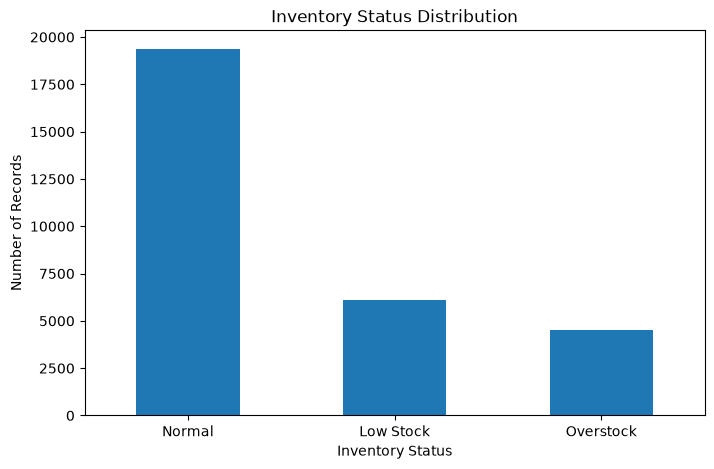

In [35]:
# Create a bar chart showing the number of records
# in each inventory category.

inventory_status_count.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Inventory Status Distribution")
plt.xlabel("Inventory Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

## Product Demand Analysis

#### Total quantity sold by product

In [36]:
# Group the data by Product_Name.
# Then calculate the total quantity sold for each product.

product_sales = (
    df.groupby("Product_Name")["Quantity_Sold"]
    .sum()
    .sort_values(ascending=False)
)

# Display the top 10 products
product_sales.head(10)

Product_Name
Notebook Pack     42193
USB-C Cable       38371
Ball Pen Pack     36323
Water Bottle      28302
Wireless Mouse    26470
Printer Paper     19806
Desk Organizer    18766
Backpack          18513
Desk Lamp         16580
Laptop Sleeve     16231
Name: Quantity_Sold, dtype: int64

#### Top 10 products by quantity sold

In [37]:
# Select the top 10 products with the highest quantity sold.

top_10_products = product_sales.head(10)

top_10_products

Product_Name
Notebook Pack     42193
USB-C Cable       38371
Ball Pen Pack     36323
Water Bottle      28302
Wireless Mouse    26470
Printer Paper     19806
Desk Organizer    18766
Backpack          18513
Desk Lamp         16580
Laptop Sleeve     16231
Name: Quantity_Sold, dtype: int64

#### Visualization

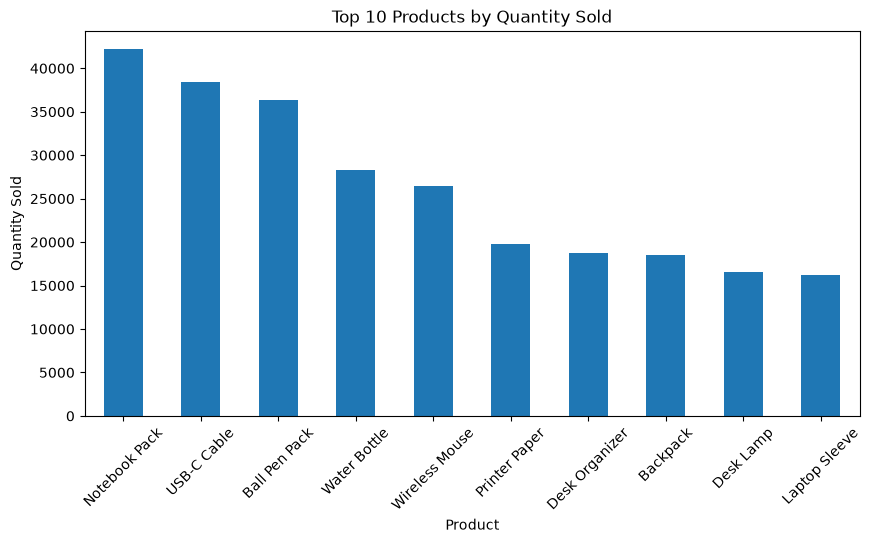

In [38]:
# Create a bar chart for the top 10 products.

top_10_products.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

# Rotate product names so they are easier to read
plt.xticks(rotation=45)

plt.show()

#### Product Revenue Analysis

In [39]:
# Group data by product and calculate total revenue.

product_revenue = (
    df.groupby("Product_Name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

# Display the top 10 products by revenue
product_revenue.head(10)

Product_Name
LED Monitor            39092007.88
Office Chair           38844409.56
Running Shoes          25892121.47
Backpack               24035936.26
Mechanical Keyboard    21350660.82
Desk Lamp              18231522.12
Study Table            17741209.84
Bluetooth Speaker      17427978.97
Power Bank             15289747.78
Bookshelf              11542048.77
Name: Revenue, dtype: float64

#### Visualization

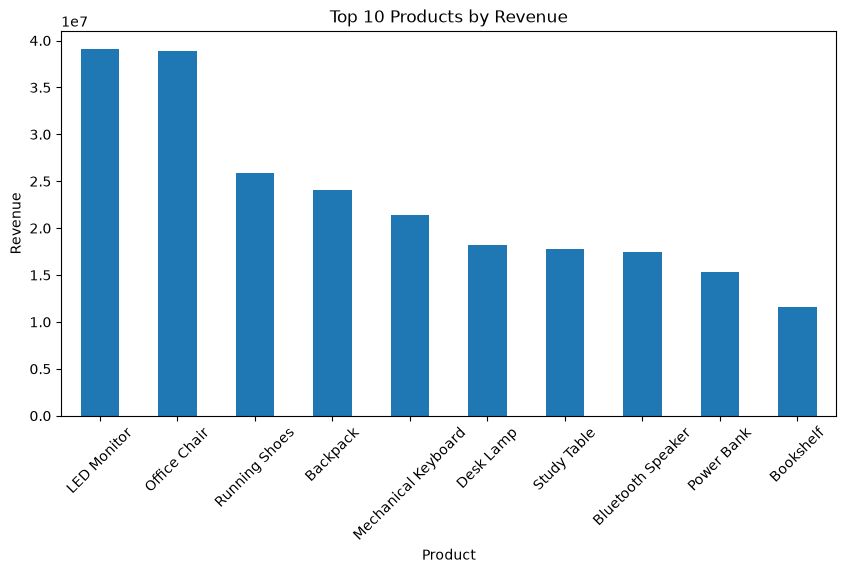

In [40]:
# Get the top 10 revenue-generating products.

top_10_revenue = product_revenue.head(10)

# Create a bar chart

top_10_revenue.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### Product Profit Analysis

In [41]:
# Group the data by product.
# Calculate total profit generated by each product.

product_profit = (
    df.groupby("Product_Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

# Display the top 10 most profitable products
product_profit.head(10)

Product_Name
Office Chair           12082490.02
LED Monitor            10851457.58
Backpack               10766572.44
Running Shoes          10202270.45
Mechanical Keyboard     7717620.74
Desk Lamp               7190375.85
Bluetooth Speaker       6889967.82
Study Table             6288981.52
Power Bank              6163119.99
Laptop Sleeve           5411095.37
Name: Profit, dtype: float64

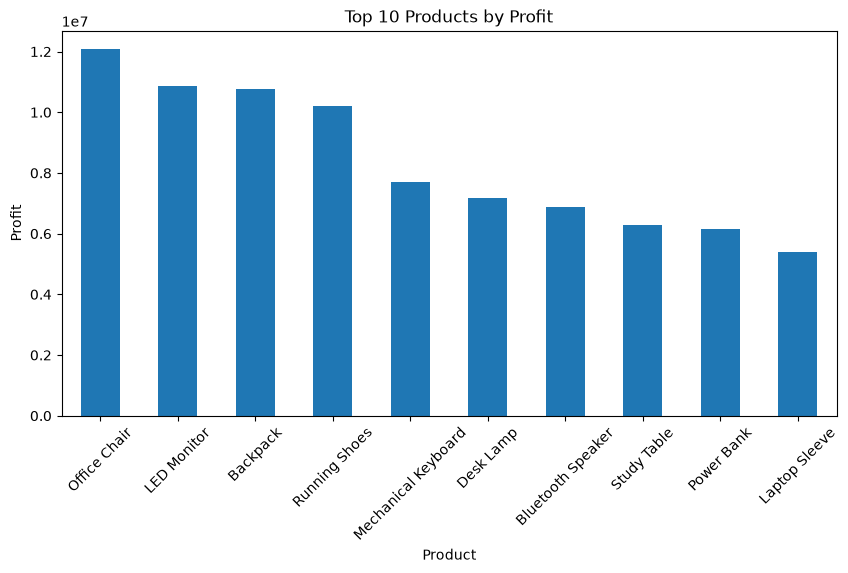

In [42]:
# Select the top 10 profitable products.

top_10_profit = product_profit.head(10)

# Create a bar chart

top_10_profit.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Product")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

## Supplier Analysis

In [43]:
supplier_revenue = (
    df.groupby("Supplier_Name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

supplier_revenue

Supplier_Name
TechSource India         39300986.60
National Distributors    38193126.71
Apex Supplies            38168990.21
Metro Wholesale          37715125.47
Global Goods India       37604783.09
Urban Supply Co          37209158.56
Reliable Traders         37019901.66
Prime Components         36668645.78
Name: Revenue, dtype: float64

In [44]:
supplier_profit = (
    df.groupby("Supplier_Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

supplier_profit

Supplier_Name
TechSource India         14721597.51
National Distributors    14348414.46
Apex Supplies            14262218.56
Metro Wholesale          14091105.81
Global Goods India       14086203.35
Urban Supply Co          13922739.83
Reliable Traders         13776681.56
Prime Components         13690926.75
Name: Profit, dtype: float64

## Supplier Delivery Performance

In [45]:
# Calculate the average delivery time for each supplier.

supplier_delivery = (
    df.groupby("Supplier_Name")["Delivery_Days"]
    .mean()
    .sort_values()
)

supplier_delivery

Supplier_Name
Apex Supplies            8.943902
Reliable Traders         8.965865
Prime Components         8.976501
TechSource India         8.983816
Global Goods India       8.986301
Urban Supply Co          9.024147
Metro Wholesale          9.029264
National Distributors    9.060616
Name: Delivery_Days, dtype: float64

#### Fastest suppliers

In [46]:
# Display the 5 suppliers with the lowest average delivery time.

print("Fastest Suppliers:")

supplier_delivery.head(5)

Fastest Suppliers:


Supplier_Name
Apex Supplies         8.943902
Reliable Traders      8.965865
Prime Components      8.976501
TechSource India      8.983816
Global Goods India    8.986301
Name: Delivery_Days, dtype: float64

#### Slowest suppliers

In [47]:
# Display the 5 suppliers with the highest average delivery time.

print("Slowest Suppliers:")

supplier_delivery.tail(5)

Slowest Suppliers:


Supplier_Name
TechSource India         8.983816
Global Goods India       8.986301
Urban Supply Co          9.024147
Metro Wholesale          9.029264
National Distributors    9.060616
Name: Delivery_Days, dtype: float64

### Supplier Performance Summary

In [48]:
# Create a supplier-level summary containing:
# 1. Total revenue
# 2. Total profit
# 3. Average delivery days
# 4. Total quantity sold

supplier_analysis = df.groupby("Supplier_Name").agg(

    # Total revenue generated
    Revenue=("Revenue", "sum"),

    # Total profit generated
    Profit=("Profit", "sum"),

    # Average delivery time
    Avg_Delivery_Days=("Delivery_Days", "mean"),

    # Total quantity sold
    Quantity_Sold=("Quantity_Sold", "sum")
)

supplier_analysis

,Revenue,Profit,Avg_Delivery_Days,Quantity_Sold
Supplier_Name,,,,
Apex Supplies,38168990.21,14262218.56,8.943902,43045
Global Goods India,37604783.09,14086203.35,8.986301,42902
Metro Wholesale,37715125.47,14091105.81,9.029264,43964
National Distributors,38193126.71,14348414.46,9.060616,44127
Prime Components,36668645.78,13690926.75,8.976501,42800
Reliable Traders,37019901.66,13776681.56,8.965865,42347
TechSource India,39300986.60,14721597.51,8.983816,44280
Urban Supply Co,37209158.56,13922739.83,9.024147,42931


In [49]:
# Sort suppliers from highest to lowest profit.

supplier_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,Revenue,Profit,Avg_Delivery_Days,Quantity_Sold
Supplier_Name,,,,
TechSource India,39300986.60,14721597.51,8.983816,44280
National Distributors,38193126.71,14348414.46,9.060616,44127
Apex Supplies,38168990.21,14262218.56,8.943902,43045
Metro Wholesale,37715125.47,14091105.81,9.029264,43964
Global Goods India,37604783.09,14086203.35,8.986301,42902
Urban Supply Co,37209158.56,13922739.83,9.024147,42931
Reliable Traders,37019901.66,13776681.56,8.965865,42347
Prime Components,36668645.78,13690926.75,8.976501,42800


#### Delivery Delay Analysis

In [50]:
# Calculate delivery delay.
#
# Positive value  = delivered late
# Zero            = delivered on time
# Negative value  = delivered earlier than expected

df["Delivery_Delay"] = (
    df["Delivery_Days"] -
    df["Lead_Time_Days"]
)

# Display the result

df[
    [
        "Supplier_Name",
        "Lead_Time_Days",
        "Delivery_Days",
        "Delivery_Delay"
    ]
].head(10)

,Supplier_Name,Lead_Time_Days,Delivery_Days,Delivery_Delay
0,TechSource India,3,2.0,-1.0
1,Metro Wholesale,9,9.0,0.0
2,National Distributors,14,12.0,-2.0
3,Reliable Traders,10,8.0,-2.0
4,Prime Components,15,13.0,-2.0
5,Apex Supplies,3,5.0,2.0
6,Prime Components,7,7.0,0.0
7,TechSource India,14,16.0,2.0
8,Reliable Traders,9,11.0,2.0
9,TechSource India,14,14.0,0.0


#### Find Delayed Orders

In [51]:
# Select orders where actual delivery time
# was greater than the expected lead time.

delayed_orders = df[
    df["Delivery_Delay"] > 0
]

delayed_orders.head(10)

,Order_ID,Order_Date,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Warehouse,Region,Quantity_Ordered,...,Delivery_Days,Order_Status,Shipping_Cost,Defective_Units,Revenue,Product_Cost,Profit,Profit_Margin,Inventory_Status,Delivery_Delay
5,ORD100005,2025-11-12,P020,Yoga Mat,Sports,S008,Apex Supplies,Mumbai WH,West,13,...,5.0,Completed,133.78,0,6840.09,3906.09,2800.22,40.938350,Normal,2.0
7,ORD100007,2025-12-11,P016,Laptop Sleeve,Accessories,S001,TechSource India,Pune WH,West,21,...,16.0,Completed,246.99,0,12821.39,6317.50,6256.90,48.800481,Low Stock,2.0
8,ORD100008,2025-06-21,P003,USB-C Cable,Electronics,S004,Reliable Traders,Bengaluru WH,South,25,...,11.0,Completed,256.59,0,5669.96,2689.62,2723.75,48.038258,Normal,2.0
11,ORD100011,2025-09-29,P019,Running Shoes,Sports,S004,Reliable Traders,Mumbai WH,West,13,...,5.0,Completed,138.46,0,39348.01,22726.86,16482.69,41.889514,Normal,2.0
15,ORD100015,2025-10-14,P004,Bluetooth Speaker,Electronics,S006,National Distributors,Pune WH,West,7,...,17.0,Completed,94.47,0,11589.41,6313.79,5181.15,44.705900,Low Stock,3.0
17,ORD100017,2025-07-15,P001,Wireless Mouse,Electronics,S003,Metro Wholesale,Delhi WH,North,15,...,8.0,Completed,115.62,0,1469.90,822.10,532.18,36.205184,Normal,3.0
22,ORD100022,2025-12-11,P020,Yoga Mat,Sports,S005,Urban Supply Co,Delhi WH,North,19,...,11.0,Completed,271.01,0,14233.68,8216.28,5746.39,40.371780,Overstock,3.0
28,ORD100028,2025-10-15,P003,USB-C Cable,Electronics,S004,Reliable Traders,Pune WH,West,23,...,6.0,Completed,210.58,0,4424.94,2061.36,2153.00,48.656027,Normal,3.0
32,ORD100032,2025-03-23,P006,LED Monitor,Electronics,S001,TechSource India,Pune WH,West,7,...,4.0,Completed,97.19,0,74143.79,49876.68,24169.92,32.598711,Normal,2.0
33,ORD100033,2025-08-17,P008,Study Table,Furniture,S002,Prime Components,Mumbai WH,West,9,...,9.0,Completed,152.68,0,31437.36,19341.36,11943.32,37.990849,Normal,3.0


In [52]:
# Calculate the percentage of orders that were delayed.

delay_rate = (
    len(delayed_orders) / len(df)
) * 100

print("Delivery Delay Rate:", round(delay_rate, 2), "%")

Delivery Delay Rate: 41.97 %


#### Supplier Delay Analysis

In [53]:
# Calculate the average delivery delay for every supplier.

supplier_delay = (
    df.groupby("Supplier_Name")["Delivery_Delay"]
    .mean()
    .sort_values(ascending=False)
)

supplier_delay

Supplier_Name
Reliable Traders         0.571196
Prime Components         0.525783
National Distributors    0.523241
Urban Supply Co          0.508371
Metro Wholesale          0.506608
Apex Supplies            0.503309
TechSource India         0.502957
Global Goods India       0.492195
Name: Delivery_Delay, dtype: float64

## Warehouse Analysis

#### Revenue by warehouse

In [54]:
# Group the data by warehouse
# and calculate total revenue.

warehouse_revenue = (
    df.groupby("Warehouse")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

warehouse_revenue

Warehouse
Hyderabad WH    60819947.48
Pune WH         60705702.24
Delhi WH        60341527.20
Mumbai WH       60271977.31
Bengaluru WH    59741563.85
Name: Revenue, dtype: float64

#### Profit by warehouse

In [55]:
# Calculate total profit generated by each warehouse.

warehouse_profit = (
    df.groupby("Warehouse")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

warehouse_profit

Warehouse
Hyderabad WH    22898599.34
Pune WH         22760391.40
Mumbai WH       22584966.15
Delhi WH        22489698.74
Bengaluru WH    22166232.20
Name: Profit, dtype: float64

#### Quantity sold by warehouse

In [56]:
# Calculate total units sold from each warehouse.

warehouse_sales = (
    df.groupby("Warehouse")["Quantity_Sold"]
    .sum()
    .sort_values(ascending=False)
)

warehouse_sales

Warehouse
Mumbai WH       70094
Delhi WH        69501
Hyderabad WH    69381
Pune WH         68974
Bengaluru WH    68446
Name: Quantity_Sold, dtype: int64

#### Warehouse summary

In [57]:
# Create one summary table containing
# the main warehouse performance metrics.

warehouse_analysis = df.groupby("Warehouse").agg(

    # Total revenue
    Revenue=("Revenue", "sum"),

    # Total profit
    Profit=("Profit", "sum"),

    # Total quantity sold
    Quantity_Sold=("Quantity_Sold", "sum"),

    # Average inventory level
    Average_Inventory=("Inventory_Level", "mean"),

    # Number of orders
    Orders=("Order_ID", "nunique")
)

warehouse_analysis

,Revenue,Profit,Quantity_Sold,Average_Inventory,Orders
Warehouse,,,,,
Bengaluru WH,59741563.85,22166232.20,68446,53.470030,5906
Delhi WH,60341527.20,22489698.74,69501,53.245750,6059
Hyderabad WH,60819947.48,22898599.34,69381,53.197837,6010
Mumbai WH,60271977.31,22584966.15,70094,54.059086,6042
Pune WH,60705702.24,22760391.40,68974,52.299515,5983


## Regional Analysis

In [58]:
# Group the data by region.
# Calculate important business metrics for each region.

region_analysis = df.groupby("Region").agg(

    # Total revenue
    Revenue=("Revenue", "sum"),

    # Total profit
    Profit=("Profit", "sum"),

    # Total quantity sold
    Quantity_Sold=("Quantity_Sold", "sum"),

    # Number of unique orders
    Orders=("Order_ID", "nunique")
)

region_analysis

,Revenue,Profit,Quantity_Sold,Orders
Region,,,,
North,6.034153e+07,22489698.74,69501,6059
South,1.205615e+08,45064831.54,137827,11916
West,1.209777e+08,45345357.55,139068,12025


In [59]:
# Display regions from highest to lowest revenue.

region_analysis.sort_values(
    "Revenue",
    ascending=False
)

,Revenue,Profit,Quantity_Sold,Orders
Region,,,,
West,1.209777e+08,45345357.55,139068,12025
South,1.205615e+08,45064831.54,137827,11916
North,6.034153e+07,22489698.74,69501,6059


## Category Analysis

In [60]:
# Group data by product category
# and calculate important performance metrics.

category_analysis = df.groupby("Category").agg(

    # Total revenue generated by category
    Revenue=("Revenue", "sum"),

    # Total profit
    Profit=("Profit", "sum"),

    # Total quantity sold
    Quantity_Sold=("Quantity_Sold", "sum"),

    # Average inventory
    Average_Inventory=("Inventory_Level", "mean"),

    # Number of orders
    Orders=("Order_ID", "nunique")
)

category_analysis

,Revenue,Profit,Quantity_Sold,Average_Inventory,Orders
Category,,,,,
Accessories,5.087497e+07,23289322.75,81812,55.969432,6739
Electronics,1.066581e+08,37343349.33,101688,46.116915,9879
Furniture,8.635919e+07,29521072.24,28370,25.639307,4386
Sports,3.725568e+07,14973923.36,22840,44.397231,2311
Stationery,2.073281e+07,7772220.15,111686,82.249663,6685


In [61]:
# Find the highest-revenue product categories.

category_analysis.sort_values(
    "Revenue",
    ascending=False
)

,Revenue,Profit,Quantity_Sold,Average_Inventory,Orders
Category,,,,,
Electronics,1.066581e+08,37343349.33,101688,46.116915,9879
Furniture,8.635919e+07,29521072.24,28370,25.639307,4386
Accessories,5.087497e+07,23289322.75,81812,55.969432,6739
Sports,3.725568e+07,14973923.36,22840,44.397231,2311
Stationery,2.073281e+07,7772220.15,111686,82.249663,6685


## Monthly Sales Analysis

#### Create month column

In [62]:
# Extract the month from Order_Date.
#
# Period("M") groups dates into monthly periods such as:
# 2026-01
# 2026-02
# 2026-03

df["Month"] = df["Order_Date"].dt.to_period("M")

In [63]:
# Group revenue by month.

monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue

Month
2025-01    23669491.11
2025-02    21967575.92
2025-03    24745256.44
2025-04    23851721.10
2025-05    22569334.78
2025-06    25925705.65
2025-07    26435120.90
2025-08    26315454.31
2025-09    23231860.13
2025-10    28464380.86
2025-11    25954963.98
2025-12    28749852.90
Freq: M, Name: Revenue, dtype: float64

#### Monthly revenue visualization

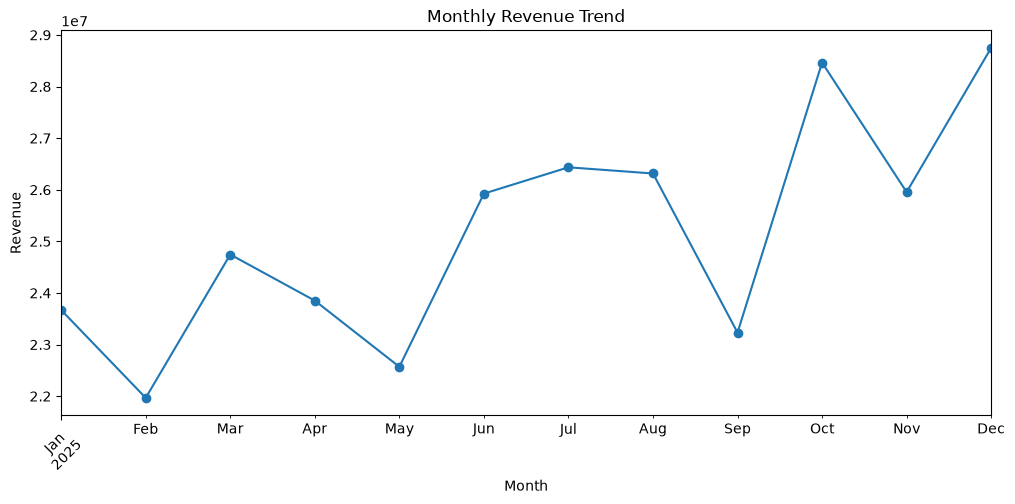

In [64]:
# Create a line chart showing how revenue changes over time.

monthly_revenue.plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

#### Monthly Profit

In [65]:
# Calculate total profit for every month.

monthly_profit = (
    df.groupby("Month")["Profit"]
    .sum()
)

monthly_profit

Month
2025-01     8824472.06
2025-02     8240306.02
2025-03     9109953.41
2025-04     8906027.93
2025-05     8518400.62
2025-06     9744514.30
2025-07     9804808.00
2025-08     9893670.66
2025-09     8693310.95
2025-10    10526240.94
2025-11     9862797.35
2025-12    10775385.59
Freq: M, Name: Profit, dtype: float64

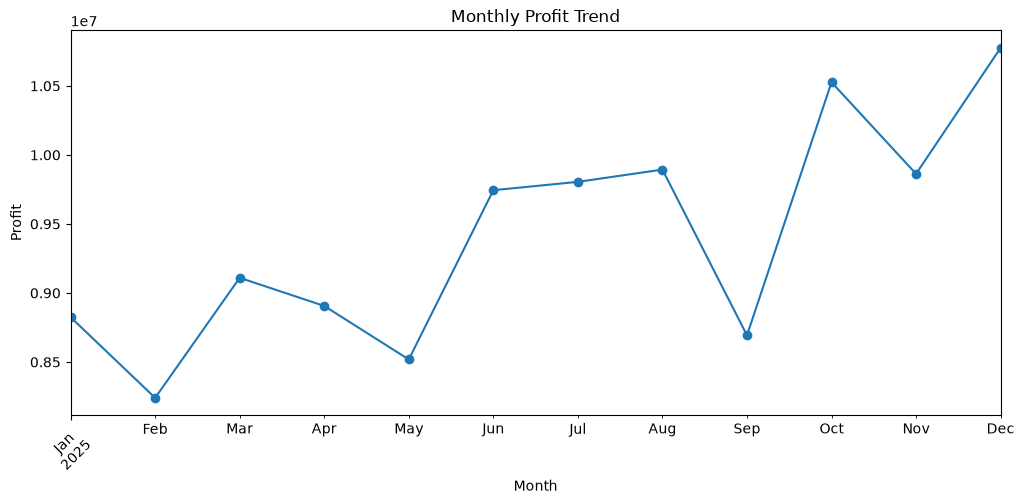

In [66]:
# Plot monthly profit.

monthly_profit.plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

## Inventory Turnover

In [67]:
# Calculate total product cost.

total_cost = df["Product_Cost"].sum()

# Calculate average inventory level.

average_inventory = df["Inventory_Level"].mean()

# Calculate inventory turnover.

inventory_turnover = (
    total_cost / average_inventory
)

print(
    "Inventory Turnover:",
    round(inventory_turnover, 2)
)

Inventory Turnover: 3449943.83


#### Overall Business KPIs

In [68]:
# Calculate total revenue.

total_revenue = df["Revenue"].sum()


# Calculate total profit.

total_profit = df["Profit"].sum()


# Count unique orders.

total_orders = df["Order_ID"].nunique()


# Calculate total units sold.

total_units = df["Quantity_Sold"].sum()


# Calculate average delivery time.

average_delivery = df["Delivery_Days"].mean()


# Calculate stockout rate.

stockout_rate = (
    (df["Inventory_Level"] == 0).mean()
) * 100


# Calculate delivery delay rate.

delay_rate = (
    (df["Delivery_Delay"] > 0).mean()
) * 100


# Calculate average profit margin.

average_profit_margin = (
    df["Profit_Margin"].mean()
)


# Display all KPIs.

print("========== SUPPLY CHAIN KPIs ==========")

print("Total Revenue:", round(total_revenue, 2))

print("Total Profit:", round(total_profit, 2))

print("Total Orders:", total_orders)

print("Total Units Sold:", total_units)

print(
    "Average Delivery Days:",
    round(average_delivery, 2)
)

print(
    "Stockout Rate:",
    round(stockout_rate, 2), "%"
)

print(
    "Delivery Delay Rate:",
    round(delay_rate, 2), "%"
)

print(
    "Average Profit Margin:",
    round(average_profit_margin, 2), "%"
)

========== SUPPLY CHAIN KPIs ==========
Total Revenue: 301880718.08
Total Profit: 112899887.83
Total Orders: 30000
Total Units Sold: 346396
Average Delivery Days: 9.0
Stockout Rate: 0.0 %
Delivery Delay Rate: 41.97 %
Average Profit Margin: -inf %


#### High-Demand + Low-Stock Products

In [69]:
# Calculate total quantity sold for every product.

product_demand = (
    df.groupby("Product_Name")["Quantity_Sold"]
    .sum()
)

In [70]:
# Calculate the average inventory level
# for each product.

product_inventory = (
    df.groupby("Product_Name")["Inventory_Level"]
    .mean()
)

In [71]:
# Combine product demand and average inventory
# into a single DataFrame.

product_analysis = pd.concat(
    [
        product_demand,
        product_inventory
    ],
    axis=1
)

# Rename the columns.

product_analysis.columns = [
    "Total_Demand",
    "Average_Inventory"
]

product_analysis.head()

,Total_Demand,Average_Inventory
Product_Name,,
Backpack,18513,38.425563
Ball Pen Pack,36323,107.589424
Bluetooth Speaker,10904,30.768662
Bookshelf,2688,9.818432
Desk Lamp,16580,43.812427


#### Find high-demand products

In [72]:
# Calculate the 75th percentile of product demand.
#
# Products above this value are considered
# high-demand products.

high_demand_threshold = (
    product_analysis["Total_Demand"]
    .quantile(0.75)
)

print(
    "High Demand Threshold:",
    high_demand_threshold
)

High Demand Threshold: 21472.0


In [73]:
# Calculate the 75th percentile of product demand.
#
# Products above this value are considered
# high-demand products.

high_demand_threshold = (
    product_analysis["Total_Demand"]
    .quantile(0.75)
)

print(
    "High Demand Threshold:",
    high_demand_threshold
)

High Demand Threshold: 21472.0


#### Find high-demand products with low inventory

In [74]:
# Calculate the median inventory level.

low_inventory_threshold = (
    product_analysis["Average_Inventory"]
    .median()
)

print(
    "Low Inventory Threshold:",
    low_inventory_threshold
)

Low Inventory Threshold: 46.11594380509521


In [75]:
# Find products that:
#
# 1. Have high demand
# 2. Have relatively low inventory
#
# These products may require urgent replenishment.

high_demand_low_stock = product_analysis[
    (product_analysis["Total_Demand"] >
     high_demand_threshold)
    &
    (product_analysis["Average_Inventory"] <
     low_inventory_threshold)
]

# Sort by demand so the highest-demand products
# appear first.

high_demand_low_stock = (
    high_demand_low_stock
    .sort_values(
        "Total_Demand",
        ascending=False
    )
)

high_demand_low_stock

,Total_Demand,Average_Inventory
Product_Name,,


## Defective Product Analysis

In [76]:
# Calculate total defective units.

total_defective = df["Defective_Units"].sum()

print(
    "Total Defective Units:",
    total_defective
)

Total Defective Units: 6122


In [77]:
# Calculate the percentage of sold units
# that were defective.

defect_rate = (
    total_defective /
    df["Quantity_Sold"].sum()
) * 100

print(
    "Defect Rate:",
    round(defect_rate, 2),
    "%"
)

Defect Rate: 1.77 %


In [78]:
# Calculate total defective units for each supplier.

supplier_defects = (
    df.groupby("Supplier_Name")["Defective_Units"]
    .sum()
    .sort_values(ascending=False)
)

supplier_defects

Supplier_Name
Apex Supplies            789
National Distributors    788
Prime Components         787
Metro Wholesale          765
TechSource India         764
Reliable Traders         760
Urban Supply Co          742
Global Goods India       727
Name: Defective_Units, dtype: int64

## Final Executive Summary

In [88]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)

kpi_summary

,KPI,Value
0,Total Revenue,301880718.08
1,Total Profit,112899887.83
2,Total Orders,30000.00
3,Total Units Sold,346396.00
4,Average Delivery Days,9.00
5,Stockout Rate (%),0.00
6,Delay Rate (%),41.97
7,Average Profit Margin (%),37.40
8,Inventory Turnover,3449943.83
9,Defect Rate (%),1.77


In [89]:
kpi_data = {
    "Total Revenue": df["Revenue"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Total Orders": total_orders,
    "Total Units Sold": total_units,
    "Average Delivery Days": average_delivery,
    "Stockout Rate (%)": stockout_rate,
    "Delay Rate (%)": delay_rate,
    "Average Profit Margin (%)": (df["Profit"].sum() / df["Revenue"].sum()) * 100,
    "Inventory Turnover": inventory_turnover,
    "Defect Rate (%)": defect_rate
}

kpi_summary = pd.DataFrame(
    list(kpi_data.items()),
    columns=["KPI", "Value"]
)

kpi_summary["Value"] = kpi_summary["Value"].round(2)

kpi_summary

,KPI,Value
0,Total Revenue,301880718.08
1,Total Profit,112899887.83
2,Total Orders,30000.00
3,Total Units Sold,346396.00
4,Average Delivery Days,9.00
5,Stockout Rate (%),0.00
6,Delay Rate (%),41.97
7,Average Profit Margin (%),37.40
8,Inventory Turnover,3449943.83
9,Defect Rate (%),1.77


## Generate Business Insights

In [80]:
# Find the highest-revenue category.

highest_revenue_category = (
    category_analysis["Revenue"]
    .idxmax()
)

print(
    "Highest Revenue Category:",
    highest_revenue_category
)


# Find the most profitable category.

highest_profit_category = (
    category_analysis["Profit"]
    .idxmax()
)

print(
    "Most Profitable Category:",
    highest_profit_category
)


# Find the highest-revenue warehouse.

best_warehouse = (
    warehouse_analysis["Revenue"]
    .idxmax()
)

print(
    "Highest Revenue Warehouse:",
    best_warehouse
)


# Find the best supplier based on profit.

best_supplier = (
    supplier_analysis["Profit"]
    .idxmax()
)

print(
    "Most Profitable Supplier:",
    best_supplier
)


# Find the slowest supplier.

slowest_supplier = (
    supplier_delivery.idxmax()
)

print(
    "Slowest Supplier:",
    slowest_supplier
)

Highest Revenue Category: Electronics
Most Profitable Category: Electronics
Highest Revenue Warehouse: Hyderabad WH
Most Profitable Supplier: TechSource India
Slowest Supplier: National Distributors
